In [2]:
import pandas as pd
import numpy as np

file= pd.read_excel("Cancer_Treatment_Performance_Global_KPIs_Dataset.xlsx")
file.describe()

,Patient_ID,Start_Date,End_Date,Treatment_Response_Score,Treatment_Cost_USD,Number_of_Cycles,Time_to_Response_Days,Follow_Up_Visits
count,450.000000,450,450,450.000000,450.000000,450.000000,450.000000,450.000000
mean,1225.500000,2023-01-11 04:03:12,2023-06-08 02:27:12,69.686222,35166.073778,6.882222,62.175556,5.122222
min,1001.000000,2022-01-02 00:00:00,2022-02-13 00:00:00,10.000000,14773.350000,3.000000,10.000000,1.000000
25%,1113.250000,2022-07-18 12:00:00,2022-12-08 00:00:00,56.500000,30301.777500,4.000000,32.000000,3.000000
50%,1225.500000,2023-01-11 00:00:00,2023-06-16 12:00:00,71.050000,34847.945000,7.000000,61.000000,5.000000
75%,1337.750000,2023-07-13 00:00:00,2023-12-08 18:00:00,82.975000,39897.135000,9.000000,91.000000,7.000000
max,1450.000000,2023-12-30 00:00:00,2024-08-27 00:00:00,100.000000,58091.610000,11.000000,119.000000,9.000000
std,130.048068,NaN,NaN,18.117293,7429.980504,2.605783,32.840545,2.513340


In [7]:
file.shape

(450, 15)

In [37]:
file.isnull().sum()


Patient_ID                  0
Diagnosis                   0
Stage                       0
Start_Date                  0
End_Date                    0
Outcome                     0
Treatment_Response_Score    0
Drug_Regimen                0
Hospital                    0
Doctor                      0
Survival_Status             0
Treatment_Cost_USD          0
Number_of_Cycles            0
Time_to_Response_Days       0
Follow_Up_Visits            0
dtype: int64

In [38]:
file.duplicated().sum()

np.int64(0)

Using Histogram plot to understand the distribution of the treatment cost among people

Text(0.5, 1.0, 'Treatment_Cost_USD')

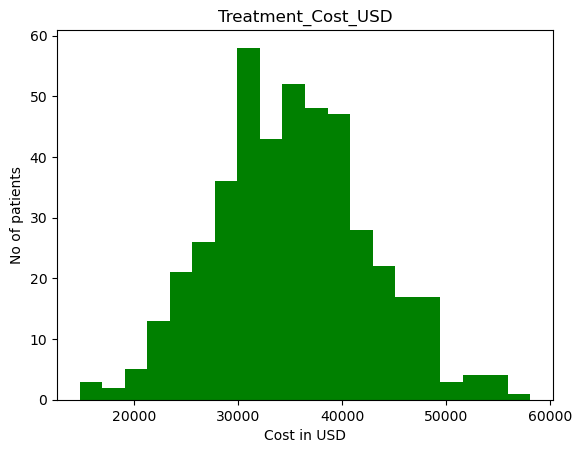

In [40]:
import matplotlib.pyplot as plt

plt.hist(file["Treatment_Cost_USD"], bins=20, color = "green") #Add lines
plt.ylabel("No of patients")
plt.xlabel("Cost in USD")
plt.title("Treatment_Cost_USD") 

Using boxplot to Understand the relationship to diagnosis_stage and Time_of_response in days

C:\Users\vssen\AppData\Local\Temp\ipykernel_9884\3999536752.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


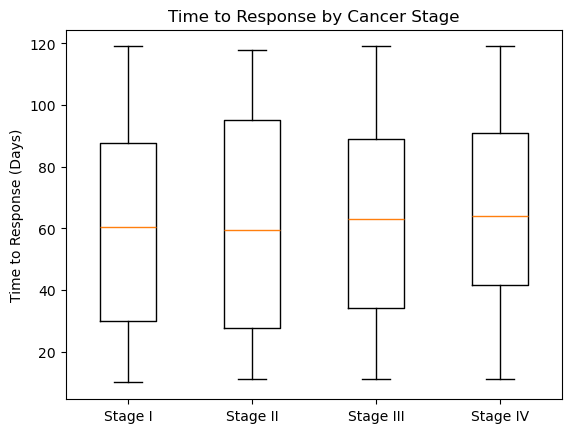

In [34]:
import matplotlib.pyplot as plt
file1 = file[file["Stage"] == "Stage I"]
file2 = file[file["Stage"] == "Stage II"]
file3 = file[file["Stage"] == "Stage III"]
file4 = file[file["Stage"] == "Stage IV"]

data = [
    file1["Time_to_Response_Days"],
    file2["Time_to_Response_Days"],
    file3["Time_to_Response_Days"],
    file4["Time_to_Response_Days"]
]

labels = ["Stage I", "Stage II", "Stage III", "Stage IV"]


plt.boxplot(data, labels=labels)
plt.ylabel("Time to Response (Days)")
plt.title("Time to Response by Cancer Stage")
plt.show()




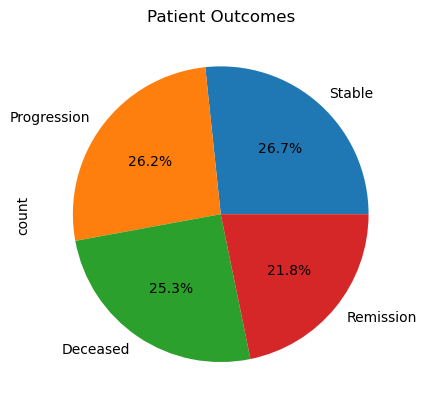

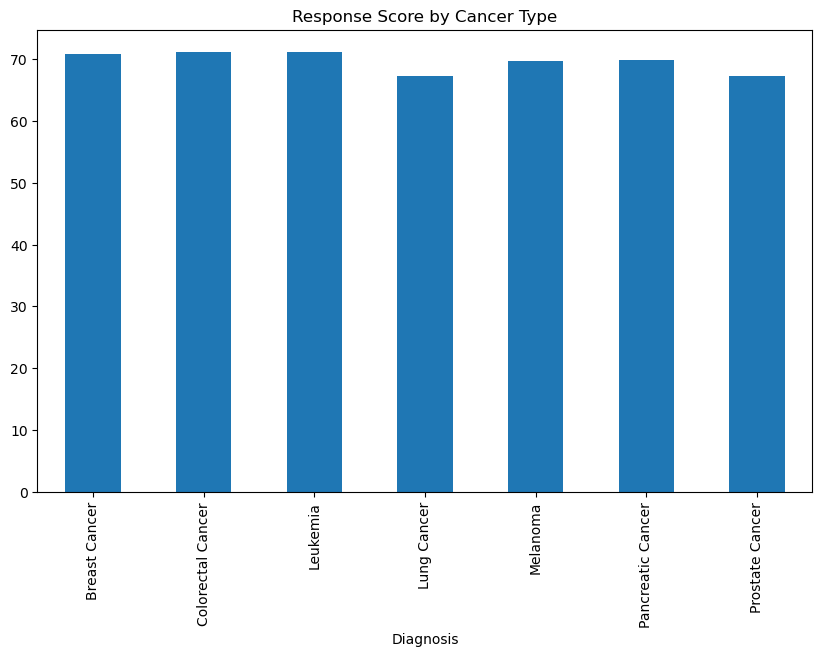

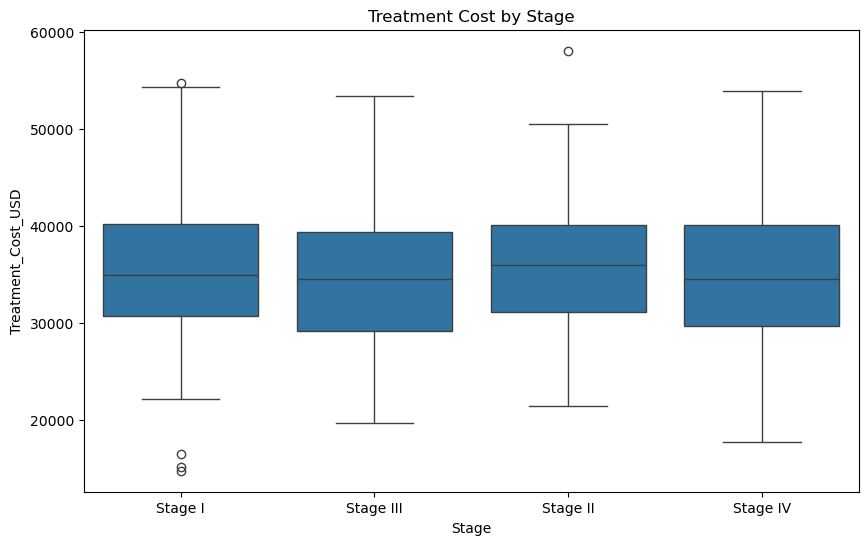

In [43]:
import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns
 
# Load data

df = pd.read_excel("Cancer_Treatment_Performance_Global_KPIs_Dataset.xlsx")
 
# 1. Outcome Pie Chart

df['Outcome'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title('Patient Outcomes')

plt.savefig('outcome_distribution.png')
 
# 2. Performance by Diagnosis

plt.figure(figsize=(10,6))

df.groupby('Diagnosis')['Treatment_Response_Score'].mean().plot(kind='bar')

plt.title('Response Score by Cancer Type')

plt.savefig('response_by_diagnosis.png')
 
# 3. Cost Analysis

plt.figure(figsize=(10,6))

sns.boxplot(x='Stage', y='Treatment_Cost_USD', data=df)

plt.title('Treatment Cost by Stage')

plt.savefig('cost_by_stage.png')
 